Study assimilation - postprocess PRO files

In [ ]:
# from edelassim.postprocess_surfex.pro import postprocess_pro
# Preprocess simulation output (assimilation of snow depth in this case)
import glob
from datetime import timedelta

import numpy as np
import xarray as xr
from pandas import date_range
from pyproj import CRS
import pandas as pd
from edelassim.postprocess_surfex.pro import postprocess_pro

simulation_folder = "/home/imperatoren/work/edelweiss_assimilation/simulations/edelweiss/grandesrousses250m/open_loop"
output_folder = "/home/imperatoren/work/edelweiss_assimilation/simulations/postprocess/grandesrousses250m/open_loop/"
filename = "all_members/pro/PRO_daily_snowdepth_avg_grandesrousses_20212022.nc"
output_file = f"{output_folder}/{filename}"


sd_analysis = postprocess_pro(simulation_folder=simulation_folder, output_file=None)

open mb0000
open mb0001
open mb0002
open mb0003
open mb0004
open mb0005
open mb0006
open mb0007
open mb0008
open mb0009
open mb0010
open mb0011
open mb0012
open mb0013
open mb0014
open mb0015
open mb0016
concatenating all members


In [30]:
from edelassim.observation_operators import dickinson

output_folder = "/home/imperatoren/work/edelweiss_assimilation/simulations/postprocess/grandesrousses250m/open_loop/"
filename = "mb0000/pro/PRO_daily_snowdepth_grandesrousses_20212022.nc"
output_file = f"{output_folder}/{filename}"


sd_analysis = sd_analysis.assign(scf=dickinson(sd_analysis.data_vars["DSN_T_ISBA"], a=1.4, b=0.11))
sd_analysis.sel(member=0).to_netcdf(output_file)

Text(0.5, 0.98, 'EDELWEISS snow depth                                           EDELWEISS snow cover fraction (Dickinson 93)                                                 VIIRS Météo-France')

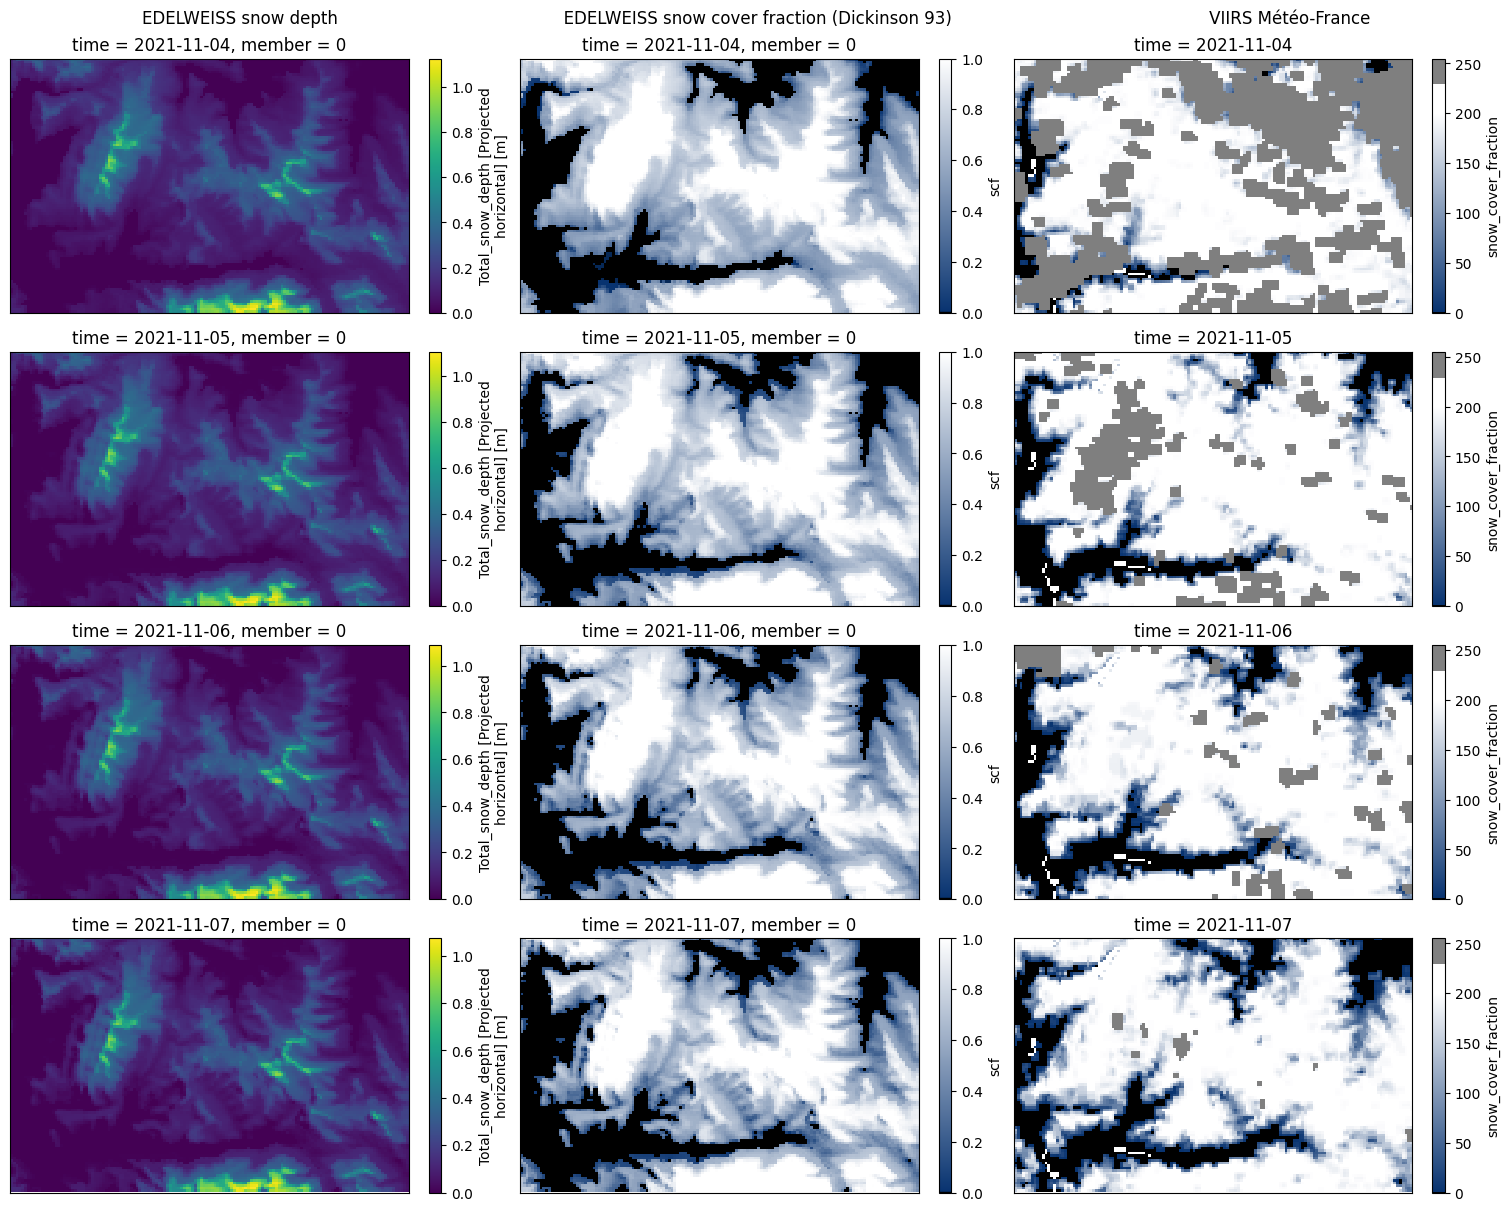

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Define color stops at specific values
fsc_color_def = [
    (0.0, (0, 0, 0)),  # 0 -> black
    (1 / 255, (8 / 255, 51 / 255, 112 / 255)),  # 1 -> light blue
    (200 / 255, (1, 1, 1)),  # 200 -> white
    (229 / 255, (1, 1, 1)),  # 200 -> white
    (230 / 255, (0.5, 0.5, 0.5)),  # 230 -> gray
    (1.0, (0.5, 0.5, 0.5)),  # 255 -> gray
]

fsc_cmap_viirs = LinearSegmentedColormap.from_list("custom_cmap", fsc_color_def, N=256)
fsc_color_def = [
    (0.0, (0, 0, 0)),  # 0 -> black
    (1 / 200, (8 / 255, 51 / 255, 112 / 255)),  # 1 -> light blue
    (200 / 200, (1, 1, 1)),  # 200 -> white
]

fsc_cmap_edel = LinearSegmentedColormap.from_list("custom_cmap", fsc_color_def, N=256)

viirs = xr.open_dataset(
    "/home/imperatoren/work/edelweiss_assimilation/data/grandesrousses/snow_cover/composite_jpss1/mf_fsc_l3_jpss1_grandesrousses_wy_2021_2022.nc"
)
fig, axs = plt.subplots(4, 3, figsize=(15, 12), constrained_layout=True)
# sd_analysis=sd_analysis.drop_vars('Projection_Type')
viirs = viirs.drop_vars("spatial_ref")
for i in range(4):
    sd_analysis.sel(time=f"2021-11-0{i + 4}", member=0).data_vars["DSN_T_ISBA"].plot.imshow(ax=axs[i, 0], cmap="viridis")
    sd_analysis.sel(time=f"2021-11-0{i + 4}", member=0).data_vars["scf"].plot.imshow(ax=axs[i, 1], cmap=fsc_cmap_edel)
    viirs.sel(time=f"2021-11-0{i + 4}").data_vars["snow_cover_fraction"].plot.imshow(ax=axs[i, 2], cmap=fsc_cmap_viirs)

plt.setp(axs, xticks=[], yticks=[], xlabel=None, ylabel=None)
plt.suptitle(
    "EDELWEISS snow depth                                           EDELWEISS snow cover fraction (Dickinson 93)                                                 VIIRS Météo-France"
)

In [ ]:
fig.savefig("/home/imperatoren/work/oslo/oslo_visit_notes/illustrations/november_situation.png")

Postprocess prep

In [11]:
from pyproj import CRS
import glob
from edelassim.postprocess_surfex.prep import compute_all_members_snow_tickness_and_mass
from edelassim.observation_operators import zaitchik

# from postprocess_surfex.prep import compute_snow_thickness_from_prep
slope_file = "/home/imperatoren/work/edelweiss_assimilation/data/auxiliary/topography/slope.tif"
new_prep_analysis = compute_all_members_snow_tickness_and_mass(
    simulation_folder=simulation_folder, slope_file=slope_file, type="analysis"
)
new_prep_analysis = new_prep_analysis.assign(
    {"fsc": zaitchik(swe=new_prep_analysis.data_vars["swe"], tau_scf=4, swe_full_snow_cover=200)}
)
filename = "all_members/prep/analysis/PREP_2022026_zaitchik.nc"
output_file = f"{output_folder}/{filename}"
new_prep_analysis.to_netcdf(output_file)

new_prep_background = compute_all_members_snow_tickness_and_mass(
    simulation_folder=simulation_folder, slope_file=slope_file, type="background"
)
new_prep_background = new_prep_background.assign(
    {"fsc": zaitchik(swe=new_prep_background.data_vars["swe"], tau_scf=4, swe_full_snow_cover=200)}
)
filename = "all_members/prep/background/PREP_2022026_zaitchik.nc"
output_file = f"{output_folder}/{filename}"
new_prep_background.to_netcdf(output_file)

In [3]:
import glob
from edelassim.postprocess_surfex.prep import compute_all_members_snow_tickness_and_mass

simulation_folder = "/home/imperatoren/work/edelweiss_assimilation/simulations/edelweiss/grandesrousses250m/assim_viirs_local"
prep_bg_files = sorted(glob.glob(f"{simulation_folder}/PREP_220226H12_PF_ENS*.nc"))
prep_an_files = sorted(glob.glob(f"{simulation_folder}/SURFOUT*.nc"))

bg = compute_all_members_snow_tickness_and_mass(
    prep_files=prep_bg_files,
    slope_file="/home/imperatoren/work/edelweiss_assimilation/data/grandesrousses/auxiliary/topography/slope.tif",
)

an = compute_all_members_snow_tickness_and_mass(
    prep_files=prep_an_files,
    slope_file="/home/imperatoren/work/edelweiss_assimilation/data/grandesrousses/auxiliary/topography/slope.tif",
)

# bg.to_netcdf(f"{simulation_folder}/prep_bg_all.nc")
an.to_netcdf(f"{simulation_folder}/prep_an_all.nc")

In [ ]:
import xarray as xr
import numpy as np


def zaitchik(swe: np.ndarray, tau_scf: int = 4, swe_full_snow_cover: int = 20) -> np.ndarray:
    return np.minimum(1 - (np.exp(-tau_scf * (swe / swe_full_snow_cover)) - (swe / swe_full_snow_cover) * np.exp(-tau_scf)), 1)


simulation_folder = "/home/imperatoren/work/edelweiss_assimilation/simulations/edelweiss/grandesrousses250m/assim_viirs_local"
background = xr.open_dataset((f"{simulation_folder}/prep_bg_all.nc"))
analysis = xr.open_dataset((f"{simulation_folder}/prep_an_all.nc"))
obs = xr.open_dataset((f"{simulation_folder}/OBSERVATIONS_220226H12.nc"))
obs = obs.rename({"xx": "x", "yy": "y"})

Text(0.5, 1.0, 'Analysis - Background')

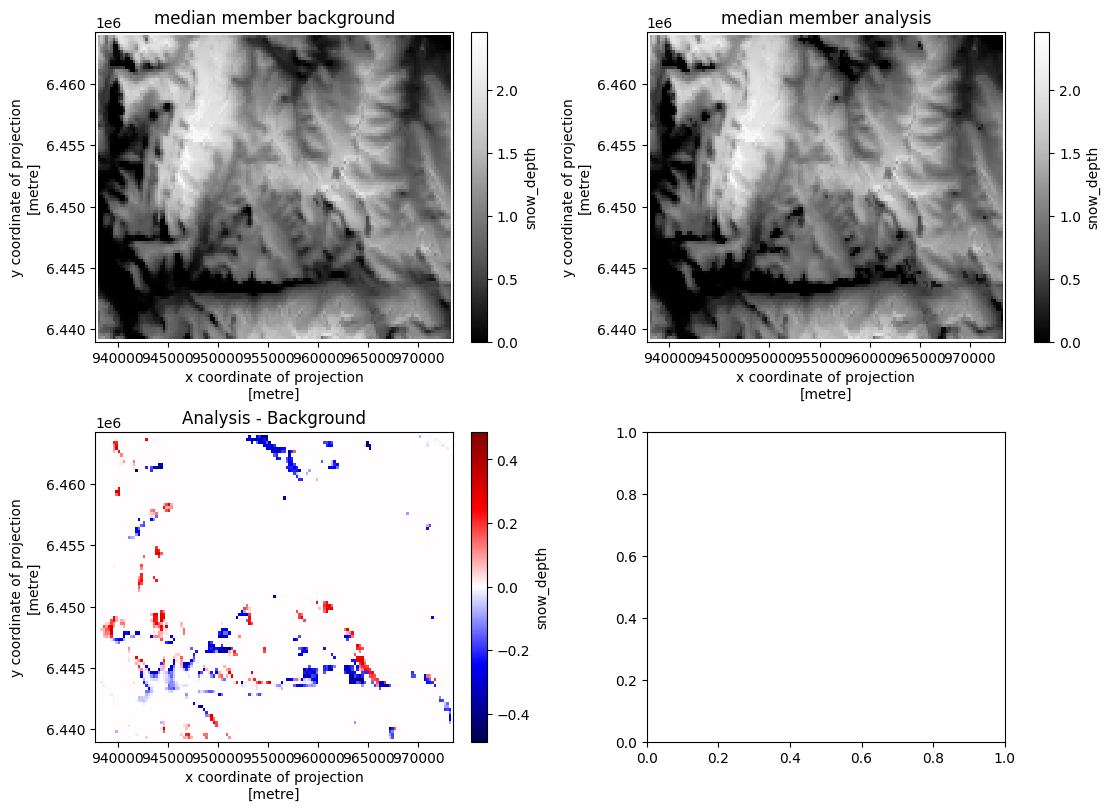

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
background.data_vars["snow_depth"].median(dim="member").plot.imshow(ax=axs[0, 0], cmap="Greys_r")
axs[0, 0].set_title("median member background")
analysis.data_vars["snow_depth"].median(dim="member").plot.imshow(ax=axs[0, 1], cmap="Greys_r")
axs[0, 1].set_title("median member analysis")
(analysis.data_vars["snow_depth"].median(dim="member") - background.data_vars["snow_depth"].median(dim="member")).plot.imshow(
    ax=axs[1, 0], cmap="seismic"
)
axs[1, 0].set_title("Analysis - Background")

Text(0.5, 1.0, 'Analysis - Background')

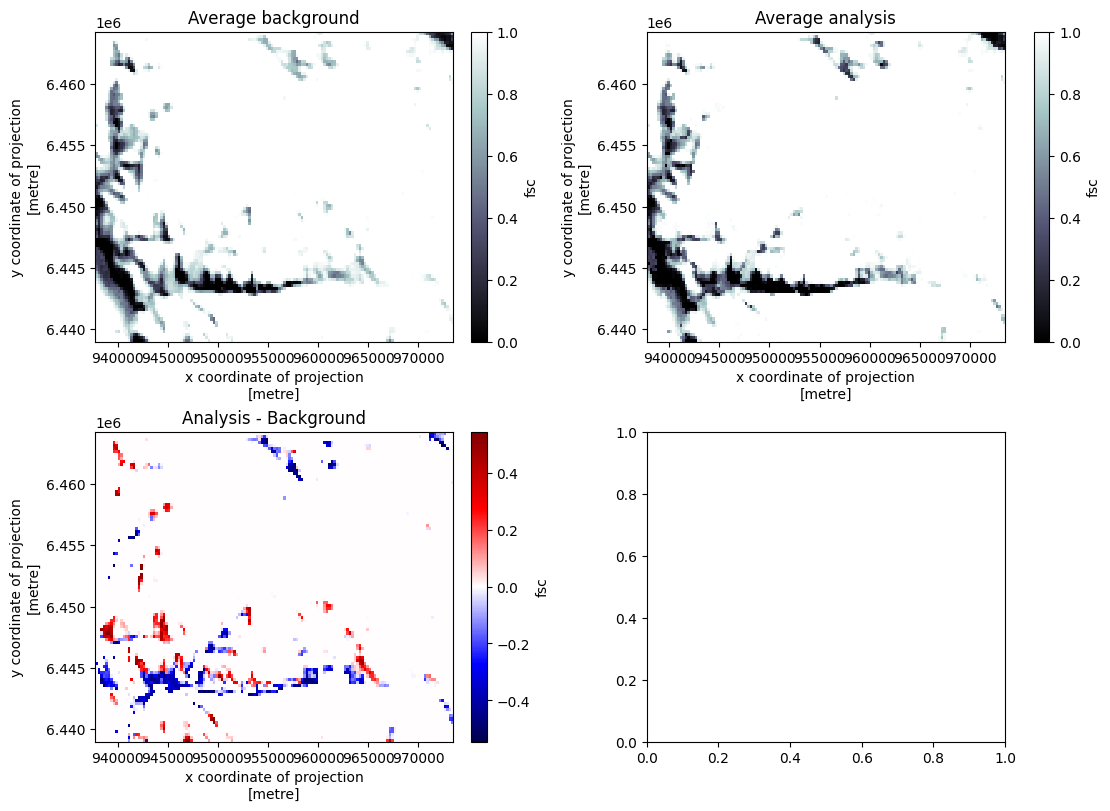

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
background = background.assign({"fsc": zaitchik(background.data_vars["swe"])})
background.mean(dim="member").data_vars["fsc"].plot.imshow(ax=axs[0, 0], cmap="bone")
axs[0, 0].set_title("Average background")
analysis = analysis.assign({"fsc": zaitchik(analysis.data_vars["swe"])})
analysis.mean(dim="member").data_vars["fsc"].plot.imshow(ax=axs[0, 1], cmap="bone")
axs[0, 1].set_title("Average analysis")
(analysis.mean(dim="member") - background.mean(dim="member")).data_vars["fsc"].plot.imshow(ax=axs[1, 0], cmap="seismic")
axs[1, 0].set_title("Analysis - Background")

Text(0.5, 1.0, '(Background - observation)@at least one member not full snow')

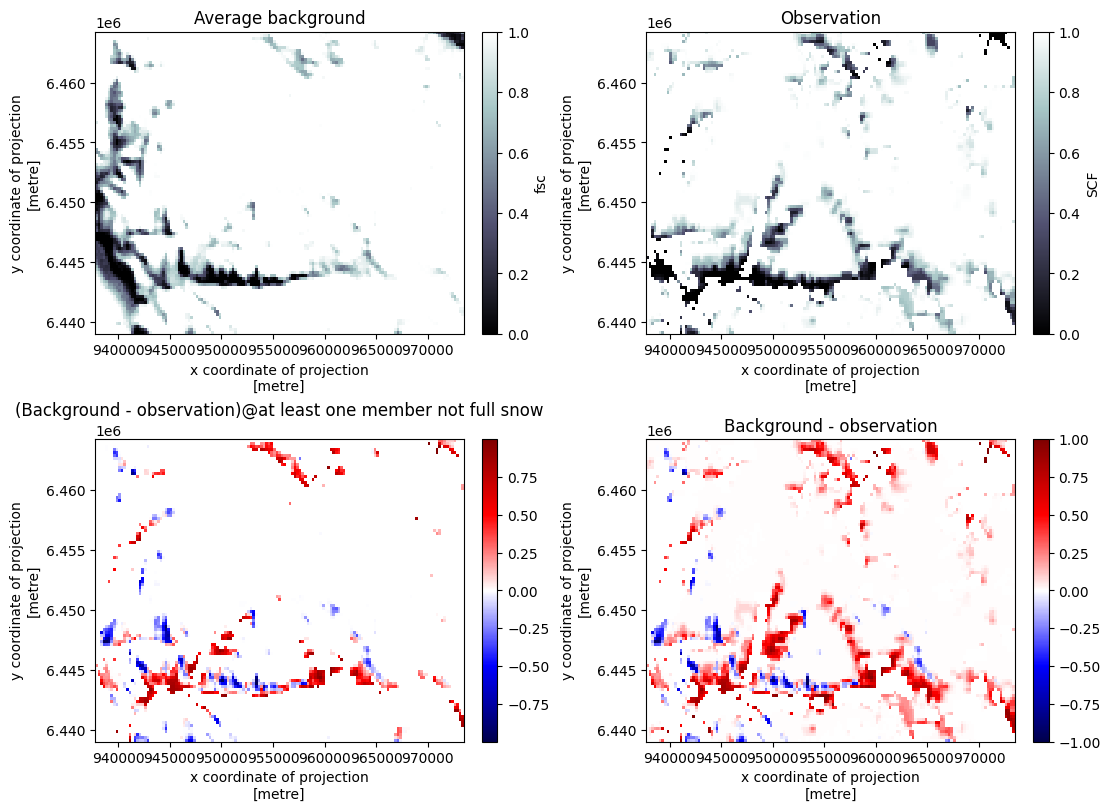

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
background = background.assign({"fsc": zaitchik(background.data_vars["swe"])})
background.mean(dim="member").data_vars["fsc"].plot.imshow(ax=axs[0, 0], cmap="bone")
axs[0, 0].set_title("Average background")
obs.data_vars["SCF"].plot.imshow(ax=axs[0, 1], cmap="bone")
axs[0, 1].set_title("Observation")
(background.mean(dim="member").data_vars["fsc"] - obs.data_vars["SCF"]).plot.imshow(ax=axs[1, 1], cmap="seismic")
axs[1, 1].set_title("Background - observation")
(background.mean(dim="member").data_vars["fsc"] - obs.data_vars["SCF"]).where(
    background.mean(dim="member").data_vars["fsc"] < 1
).plot.imshow(ax=axs[1, 0], cmap="seismic")
axs[1, 0].set_title("(Background - observation)@at least one member not full snow")

Text(0.5, 1.0, '(Analysis - observation)@at least one member not full snow')

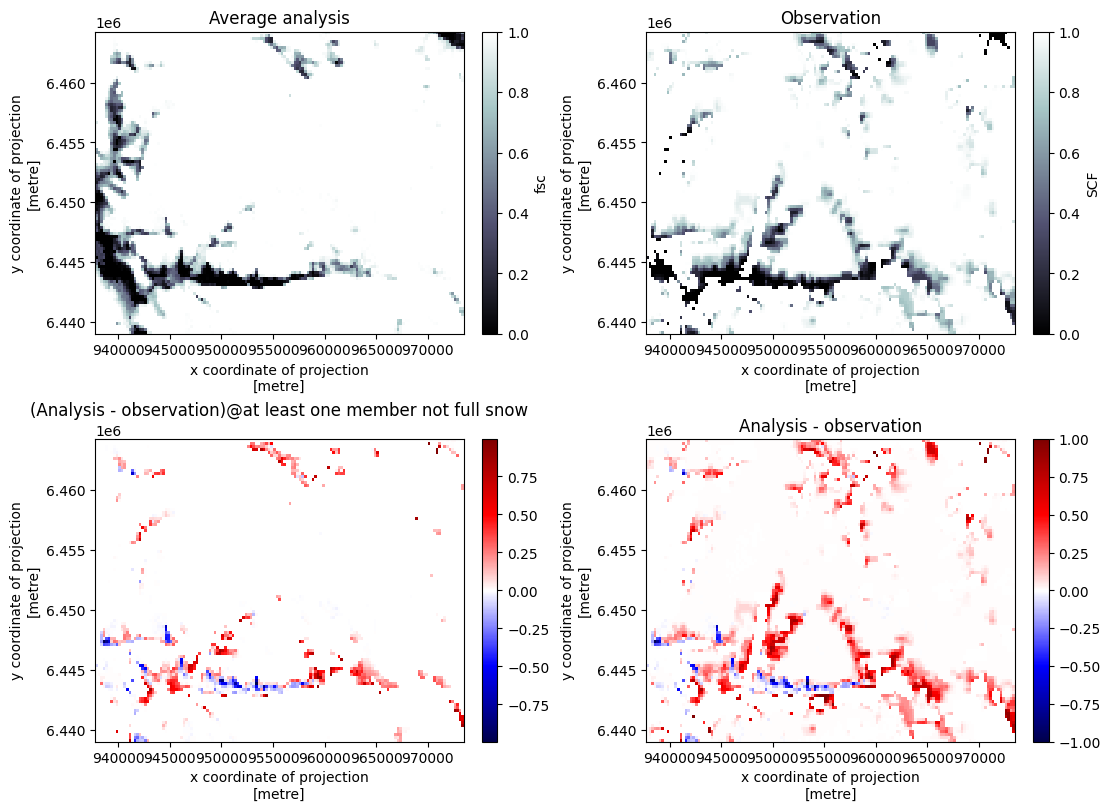

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
analysis = analysis.assign({"fsc": zaitchik(analysis.data_vars["swe"])})
analysis.mean(dim="member").data_vars["fsc"].plot.imshow(ax=axs[0, 0], cmap="bone")
axs[0, 0].set_title("Average analysis")
obs.data_vars["SCF"].plot.imshow(ax=axs[0, 1], cmap="bone")
axs[0, 1].set_title("Observation")
(analysis.mean(dim="member").data_vars["fsc"] - obs.data_vars["SCF"]).plot.imshow(ax=axs[1, 1], cmap="seismic")
axs[1, 1].set_title("Analysis - observation")
# In the where we look in the background because that's where assimilation was active
(analysis.mean(dim="member").data_vars["fsc"] - obs.data_vars["SCF"]).where(
    background.mean(dim="member").data_vars["fsc"] < 1
).plot.imshow(ax=axs[1, 0], cmap="seismic")
axs[1, 0].set_title("(Analysis - observation)@at least one member not full snow")

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(6, 11), constrained_layout=True)
background = background.assign({"fsc": zaitchik(background.data_vars["swe"])})
background.mean(dim="member").data_vars["fsc"].plot.imshow(ax=axs[0], cmap="bone")
axs[0].set_title("Average background")
obs.data_vars["SCF"].plot.imshow(ax=axs[1], cmap="bone")
axs[1].set_title("Observation")
(background.mean(dim="member").data_vars["fsc"] - obs.data_vars["SCF"]).plot.imshow(ax=axs[2], cmap="seismic")
axs[2].set_title("Background - observation")

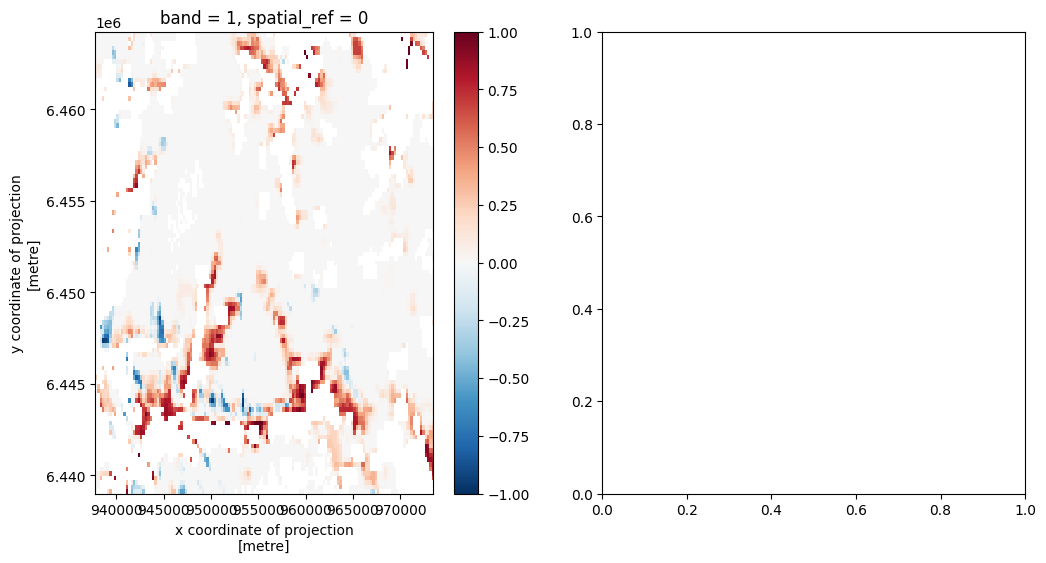

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
# obs = obs.rename({'xx': 'x', 'yy': 'y'})
(background.mean(dim="member").data_vars["fsc"] - obs.data_vars["SCF"]).plot.imshow(ax=axs[0])